<a href="https://colab.research.google.com/github/Gabriel-gnsct/Projeto-Unic-rnios/blob/main/Projeto_unic%C3%B3rnios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Na industria, startups privadas avaliadas em mais de US$1.000.000.000 (1 bilhão) são frequentemente identificadas como (unicórnio). Esse termo foi popularizado pela em 2013, pela investidora de capital de risco Aileen Lee, fundadora da Cowboy Ventures, uma empresa voltada para capital de risco de startups, localizada na California.

Este estudo tem como objetivo analisar a evolução das startups em território americano até o ano de 2022.

O link para download do arquivo pode ser consultado no site da kaggle: https://www.kaggle.com/datasets/ramjasmaurya/unicorn-startups/data

##**Importação das bibliotecas**

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##**Leitura dos dados e verificação das dimensões**

In [13]:
Base_Dados = pd.read_csv('unicorns till sep 2022.csv')
Base_Dados.shape

(1186, 7)

##**Visualização inicial dos dados**

In [14]:
Base_Dados.head()

,Company,Valuation ($B),Date Joined,Country,City,Industry,Investors
0,ByteDance,$140,4/7/2017,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$127,12/1/2012,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100,7/3/2018,China,Shenzhen,E-commerce & direct-to-consumer,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95,1/23/2014,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG"
4,Canva,$40,1/8/2018,Australia,Surry Hills,Internet software & services,"Sequoia Capital China, Blackbird Ventures, Mat..."


##**Identificação das variáveis**

In [15]:
Base_Dados.columns

Index(['Company', 'Valuation ($B)', 'Date Joined', 'Country', 'City ',
       'Industry', 'Investors'],
      dtype='object')

##**Renomeando as variáveis para português**

In [16]:
Base_Dados.rename(columns= {
    'Company' : 'Empresa',
    'Valuation ($B)' :'Valor ($B)',
    'Date Joined' : 'Data de Entrada',
    'Country' : 'Pais',
    'City\xa0':'Cidade',
    'Industry':'Setor',
    'Investors':'Investidores'



}, inplace=True)

##**Verificação do tipo dos dados**

In [17]:
Base_Dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1186 entries, 0 to 1185
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Empresa          1186 non-null   object
 1   Valor ($B)       1186 non-null   object
 2   Data de Entrada  1186 non-null   object
 3   Pais             1186 non-null   object
 4   Cidade           1186 non-null   object
 5   Setor            1186 non-null   object
 6   Investidores     1168 non-null   object
dtypes: object(7)
memory usage: 65.0+ KB


##**Alteração do tipo das variáveis**

### Valor ($B) == float64
### Data de entrada == datetime

In [18]:
Base_Dados['Valor ($B)'] = Base_Dados['Valor ($B)'].astype(str).str.replace('$', '', regex=False).astype(float)
Base_Dados['Data de Entrada'] = pd.to_datetime(Base_Dados['Data de Entrada'])
Base_Dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1186 entries, 0 to 1185
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Empresa          1186 non-null   object        
 1   Valor ($B)       1186 non-null   float64       
 2   Data de Entrada  1186 non-null   datetime64[ns]
 3   Pais             1186 non-null   object        
 4   Cidade           1186 non-null   object        
 5   Setor            1186 non-null   object        
 6   Investidores     1168 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 65.0+ KB


##**Extrair ano e mês**

In [19]:
Base_Dados['Mes'] = pd.DatetimeIndex(Base_Dados['Data de Entrada']).month
Base_Dados['Ano'] = pd.DatetimeIndex(Base_Dados['Data de Entrada']).year
Base_Dados.head()

,Empresa,Valor ($B),Data de Entrada,Pais,Cidade,Setor,Investidores,Mes,Ano
0,ByteDance,140.0,2017-04-07,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S...",4,2017
1,SpaceX,127.0,2012-12-01,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen...",12,2012
2,SHEIN,100.0,2018-07-03,China,Shenzhen,E-commerce & direct-to-consumer,"Tiger Global Management, Sequoia Capital China...",7,2018
3,Stripe,95.0,2014-01-23,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG",1,2014
4,Canva,40.0,2018-01-08,Australia,Surry Hills,Internet software & services,"Sequoia Capital China, Blackbird Ventures, Mat...",1,2018


##**Adicionar a variável continente**

###Mesmo com o principal interesse sendo o continente Americano, os outros continentes também organizados para futuras comparações dentro da análise.

In [20]:
def get_continent(country):
    if country in ['Bahamas', 'Bermuda', 'United States', 'Canada', 'Mexico', 'Brazil', 'Argentina', 'Chile', 'Colombia', 'Peru', 'Ecuador', 'Venezuela']:
        return 'América'
    elif country in ['China', 'India', 'Japan', 'South Korea', 'Indonesia', 'Singapore', 'Israel', 'United Arab Emirates', 'Hong Kong', 'Taiwan', 'Vietnam', 'Philippines', 'Malaysia', 'Thailand', 'Pakistan', 'Saudi Arabia', 'Cambodia']:
        return 'Ásia'
    elif country in ['United Kingdom', 'Germany', 'France', 'Netherlands', 'Sweden', 'Switzerland', 'Ireland', 'Spain', 'Finland', 'Belgium', 'Norway', 'Denmark', 'Italy', 'Estonia', 'Lithuania', 'Austria', 'Luxembourg', 'Poland', 'Czech Republic', 'Portugal', 'Russia', 'Turkey', 'Ukraine', 'Hungary', 'Slovakia', 'Croatia', 'Bulgaria', 'Romania']:
        return 'Europa'
    elif country in ['Australia', 'New Zealand']:
        return 'Oceania'
    elif country in ['South Africa', 'Nigeria', 'Egypt', 'Kenya','Seychelles', 'Senegal']:
        return 'África'
    else:
        return 'Outros'

Base_Dados['Continente'] = Base_Dados['Pais'].apply(get_continent)
Base_Dados.head()

,Empresa,Valor ($B),Data de Entrada,Pais,Cidade,Setor,Investidores,Mes,Ano,Continente
0,ByteDance,140.0,2017-04-07,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S...",4,2017,Ásia
1,SpaceX,127.0,2012-12-01,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen...",12,2012,América
2,SHEIN,100.0,2018-07-03,China,Shenzhen,E-commerce & direct-to-consumer,"Tiger Global Management, Sequoia Capital China...",7,2018,Ásia
3,Stripe,95.0,2014-01-23,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG",1,2014,América
4,Canva,40.0,2018-01-08,Australia,Surry Hills,Internet software & services,"Sequoia Capital China, Blackbird Ventures, Mat...",1,2018,Oceania


##**Avaliação do valor total ($B) investidos em unicórnios por continente**

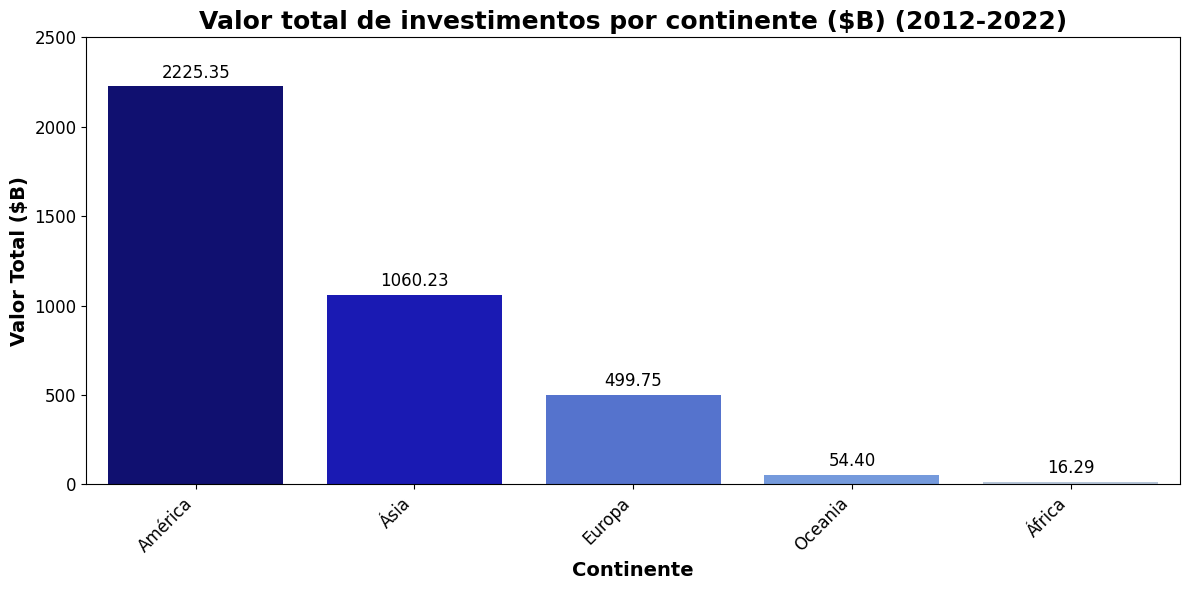

In [21]:
custom_palette = {'América': 'navy', 'Ásia': 'mediumblue', 'Europa': 'royalblue', 'Oceania': 'cornflowerblue', 'África': 'lightsteelblue', 'Outros': 'lightgray'}

valor_por_continente = Base_Dados.groupby('Continente')['Valor ($B)'].sum().reset_index().sort_values(by='Valor ($B)', ascending=False);
plt.figure(figsize=(12, 6));
ax = sns.barplot(x='Continente', y='Valor ($B)', data=valor_por_continente, palette=custom_palette, hue='Continente', legend=False);
plt.title('Valor total de investimentos por continente ($B) (2012-2022)', fontsize=18, fontweight='bold');
plt.xlabel('Continente', fontsize=14, fontweight='bold');
plt.ylabel('Valor Total ($B)', fontsize=14, fontweight='bold');
plt.grid(axis='y', linestyle='--', alpha=0.0);
plt.xticks(rotation=45, ha='right', fontsize=12);
plt.yticks(fontsize=12);
plt.ylim(0, 2500);

#
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=12);

plt.tight_layout();
plt.show();

##**Visualizar a quantidade de unicórnios por continente**

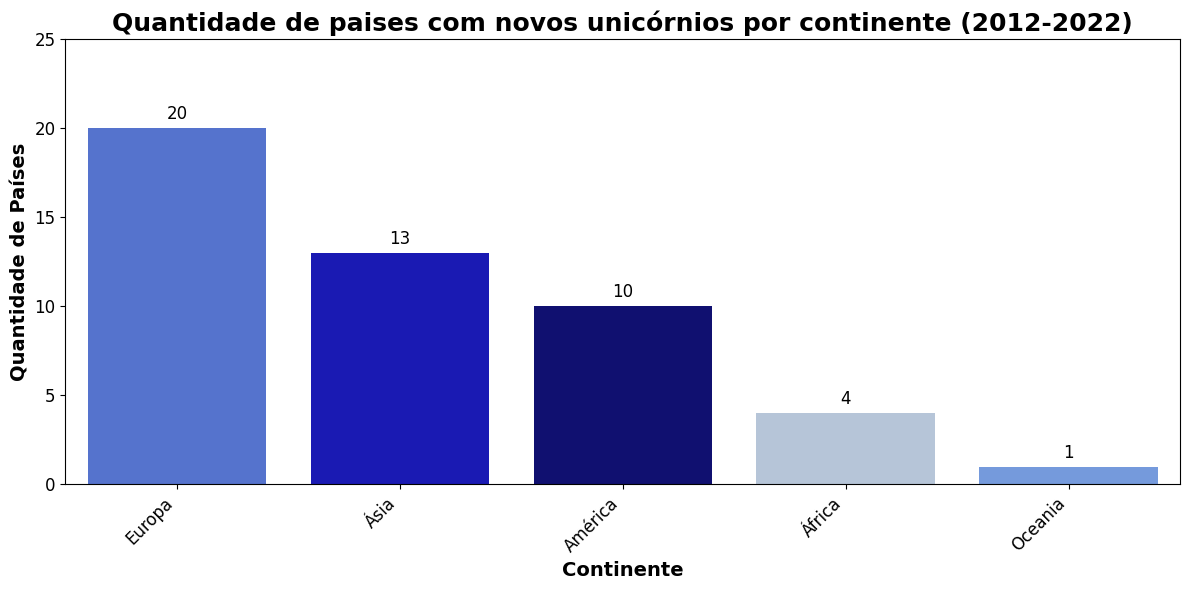

In [22]:
custom_palette = {'América': 'navy', 'Ásia': 'mediumblue', 'Europa': 'royalblue', 'Oceania': 'cornflowerblue', 'África': 'lightsteelblue', 'Outros': 'lightgray'}

# Gráfico de Quantidade de países por continente
paises_por_continente = Base_Dados.groupby('Continente')['Pais'].nunique().reset_index();
paises_por_continente.columns = ['Continente', 'Quantidade de Países'];
paises_por_continente = paises_por_continente.sort_values(by='Quantidade de Países', ascending=False);

plt.figure(figsize=(12, 6));
ax = sns.barplot(x='Continente', y='Quantidade de Países', data=paises_por_continente, palette=custom_palette, hue='Continente', legend=False);
plt.title('Quantidade de paises com novos unicórnios por continente (2012-2022)', fontsize=18, fontweight='bold');
plt.xlabel('Continente', fontsize=14, fontweight='bold');
plt.ylabel('Quantidade de Países', fontsize=14, fontweight='bold');
plt.grid(axis='y', linestyle='--', alpha=0.0);
plt.xticks(rotation=45, ha='right', fontsize=12);
plt.yticks(fontsize=12);
plt.ylim(0, 25.00);


for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=12);

plt.tight_layout();
plt.show();

##**Evolução temporal do número de unicórnios criados por ano**
###Comparação entre os continentes

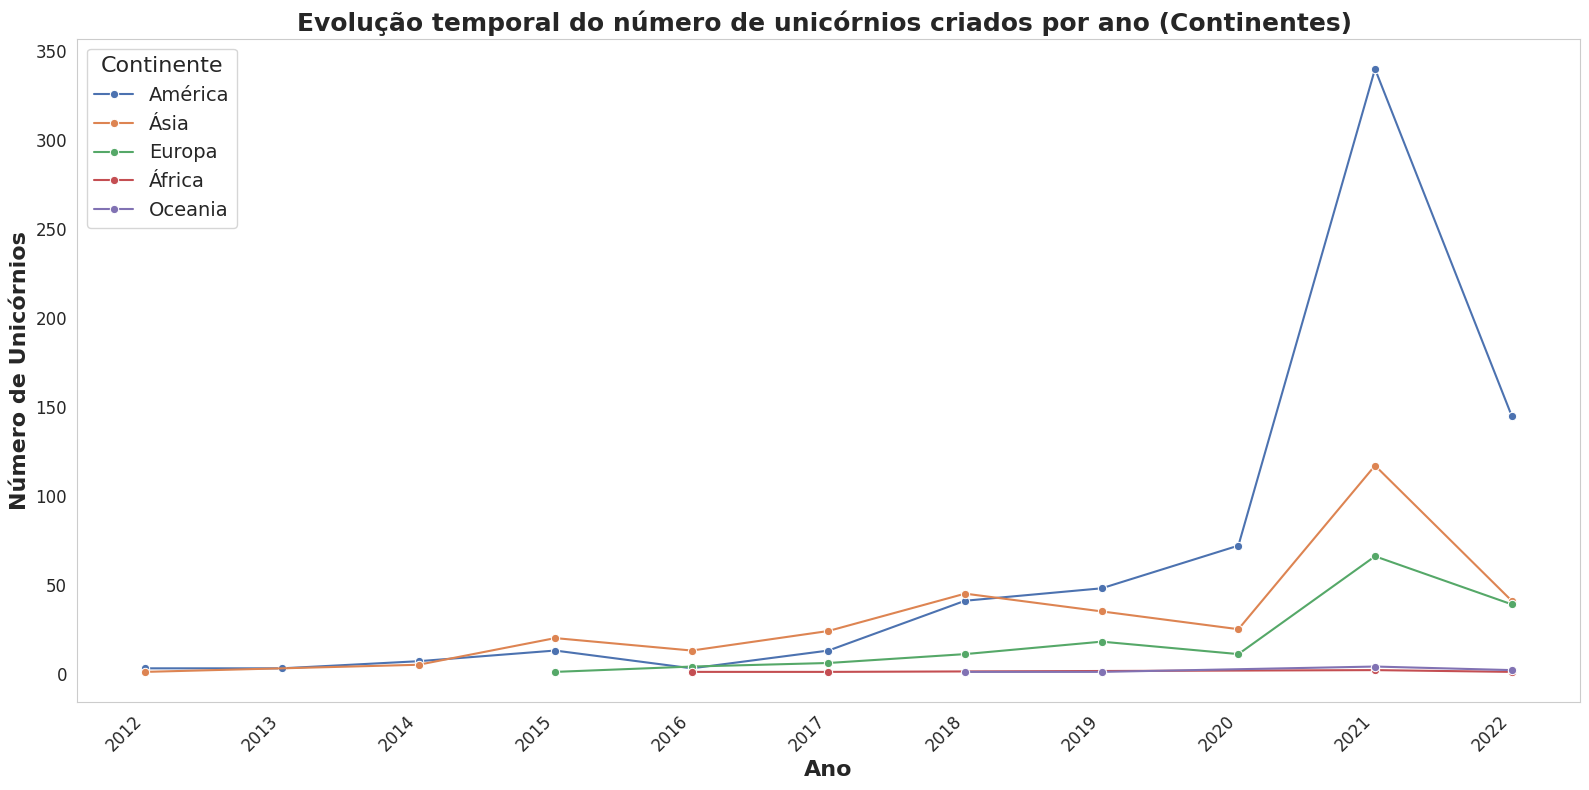

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar dados a partir de 2012
data_filtered = Base_Dados[Base_Dados['Ano'] >= 2012]

# Agrupar por ano e continente e contar o número de unicórnios
unicornios_por_ano_continente = data_filtered.groupby(['Ano', 'Continente'])['Empresa'].count().reset_index()
unicornios_por_ano_continente.rename(columns={'Empresa': 'Número de Unicórnios'}, inplace=True)

# Configurar o estilo do gráfico
sns.set_style('whitegrid')
plt.figure(figsize=(16, 8))

# Plotar o gráfico de linhas
ax = sns.lineplot(x='Ano', y='Número de Unicórnios', hue='Continente', data=unicornios_por_ano_continente, marker='o', palette='deep')

plt.title('Evolução temporal do número de unicórnios criados por ano (Continentes) ', fontsize=18, fontweight='bold')
plt.xlabel('Ano', fontsize=16, fontweight='bold') # Increased font size
plt.ylabel('Número de Unicórnios', fontsize=16, fontweight='bold') # Increased font size
plt.xticks(data_filtered['Ano'].unique().astype(int), rotation=45, ha='right', fontsize=12) # Ajusta os ticks do eixo x para mostrar todos os anos
plt.yticks(fontsize=12)
plt.legend(title='Continente', title_fontsize='16', fontsize='14', loc='upper left') # Increased font size
plt.grid(False) # Removed all grid lines
plt.tight_layout()
plt.show()

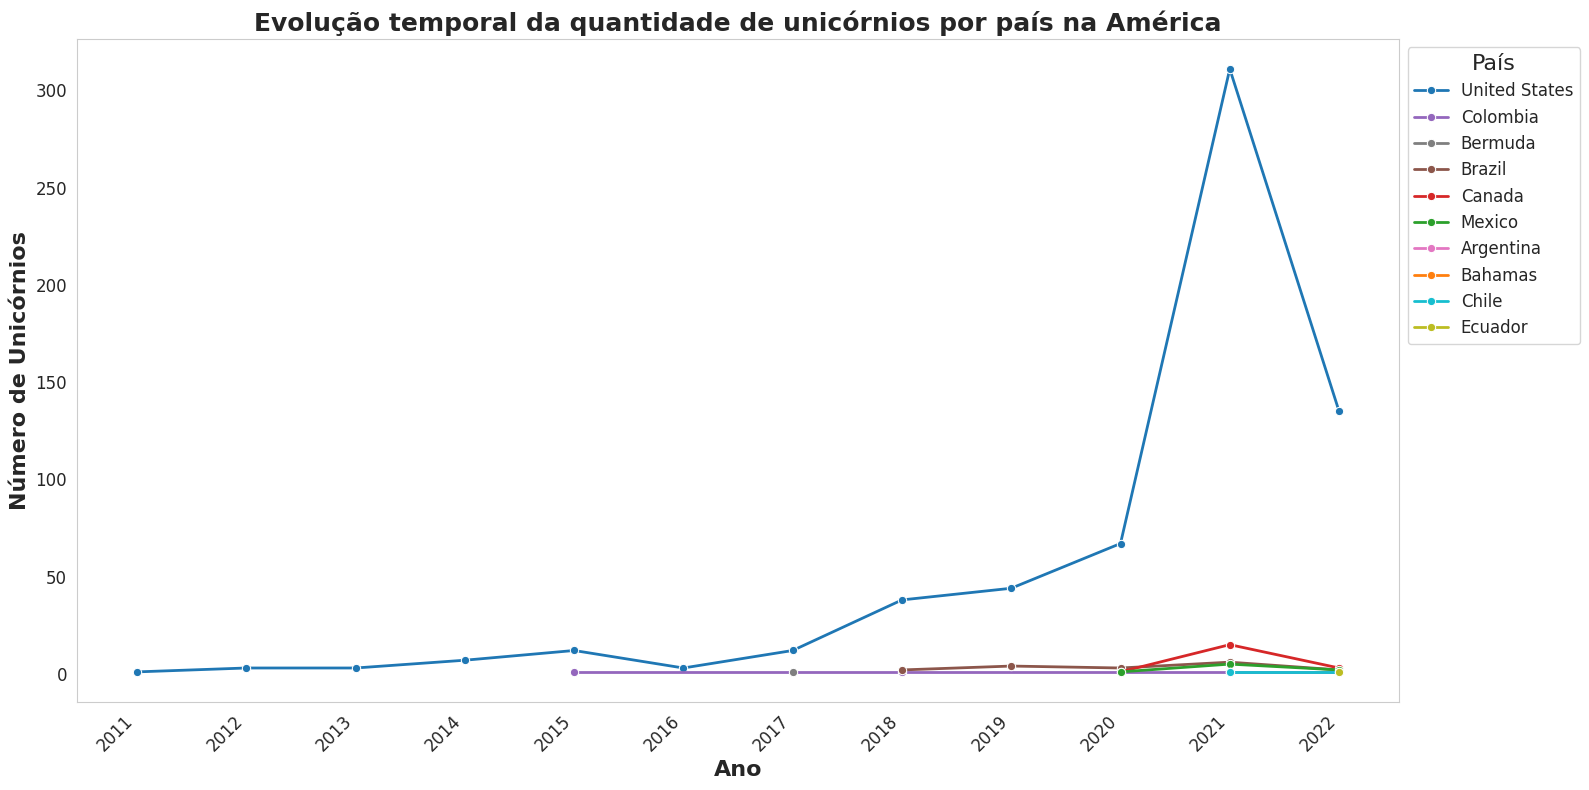

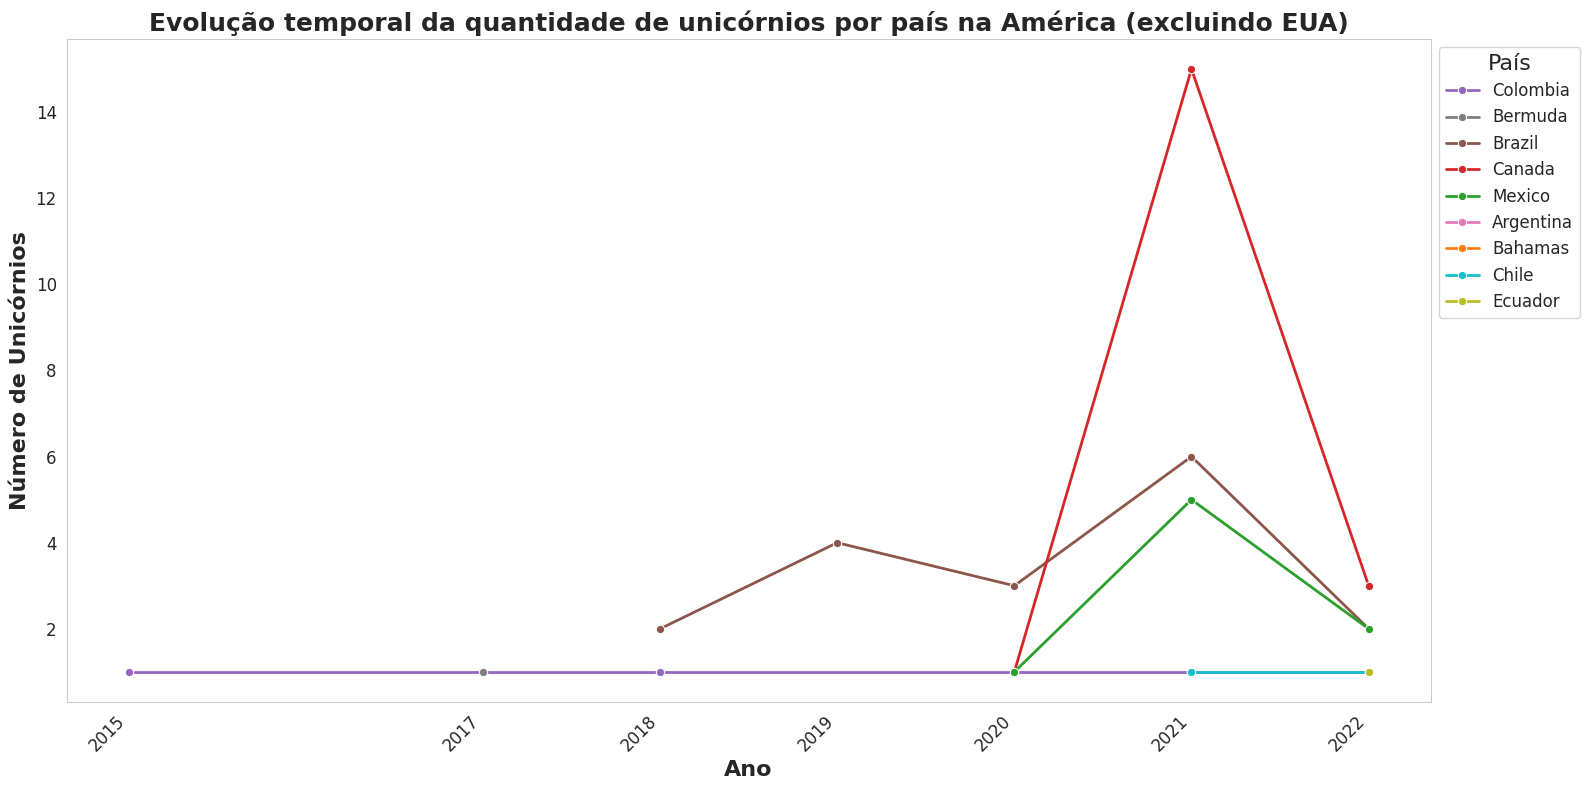

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

america_unicorns = Base_Dados[Base_Dados['Continente'] == 'América'].copy()

unicorns_by_year_country_america = america_unicorns.groupby(['Ano', 'Pais'])['Empresa'].count().reset_index()
unicorns_by_year_country_america.rename(columns={'Empresa': 'Número de Unicórnios'}, inplace=True)

all_american_countries = america_unicorns['Pais'].unique()

country_palette = sns.color_palette('tab10', n_colors=len(all_american_countries))

country_color_map = dict(zip(all_american_countries, country_palette))

sns.set_style('whitegrid')
plt.figure(figsize=(16, 8))

ax = sns.lineplot(x='Ano', y='Número de Unicórnios', hue='Pais', data=unicorns_by_year_country_america, marker='o', linewidth=2, palette=country_color_map)

plt.title('Evolução temporal da quantidade de unicórnios por país na América', fontsize=18, fontweight='bold')
plt.xlabel('Ano', fontsize=16, fontweight='bold')
plt.ylabel('Número de Unicórnios', fontsize=16, fontweight='bold')
plt.xticks(unicorns_by_year_country_america['Ano'].unique().astype(int), rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='País', title_fontsize='16', fontsize='12', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(False)
plt.tight_layout()
plt.show()


america_unicorns_no_usa = america_unicorns[america_unicorns['Pais'] != 'United States'].copy()

unicorns_by_year_country_america_no_usa = america_unicorns_no_usa.groupby(['Ano', 'Pais'])['Empresa'].count().reset_index()
unicorns_by_year_country_america_no_usa.rename(columns={'Empresa': 'Número de Unicórnios'}, inplace=True)

sns.set_style('whitegrid')
plt.figure(figsize=(16, 8))


ax_no_usa = sns.lineplot(
    x='Ano',
    y='Número de Unicórnios',
    hue='Pais',
    data=unicorns_by_year_country_america_no_usa,
    marker='o',
    linewidth=2,
    palette=country_color_map
)

plt.title('Evolução temporal da quantidade de unicórnios por país na América (excluindo EUA)', fontsize=18, fontweight='bold')
plt.xlabel('Ano', fontsize=16, fontweight='bold')
plt.ylabel('Número de Unicórnios', fontsize=16, fontweight='bold')


if not unicorns_by_year_country_america_no_usa.empty:
    plt.xticks(unicorns_by_year_country_america_no_usa['Ano'].unique().astype(int), rotation=45, ha='right', fontsize=12)
else:
    plt.xticks(fontsize=12)

plt.yticks(fontsize=12)
plt.legend(title='País', title_fontsize='16', fontsize='12', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(False)
plt.tight_layout()
plt.show()

##**Evolução temporal do valor total de unicórnios: América vs. Resto do mundo**

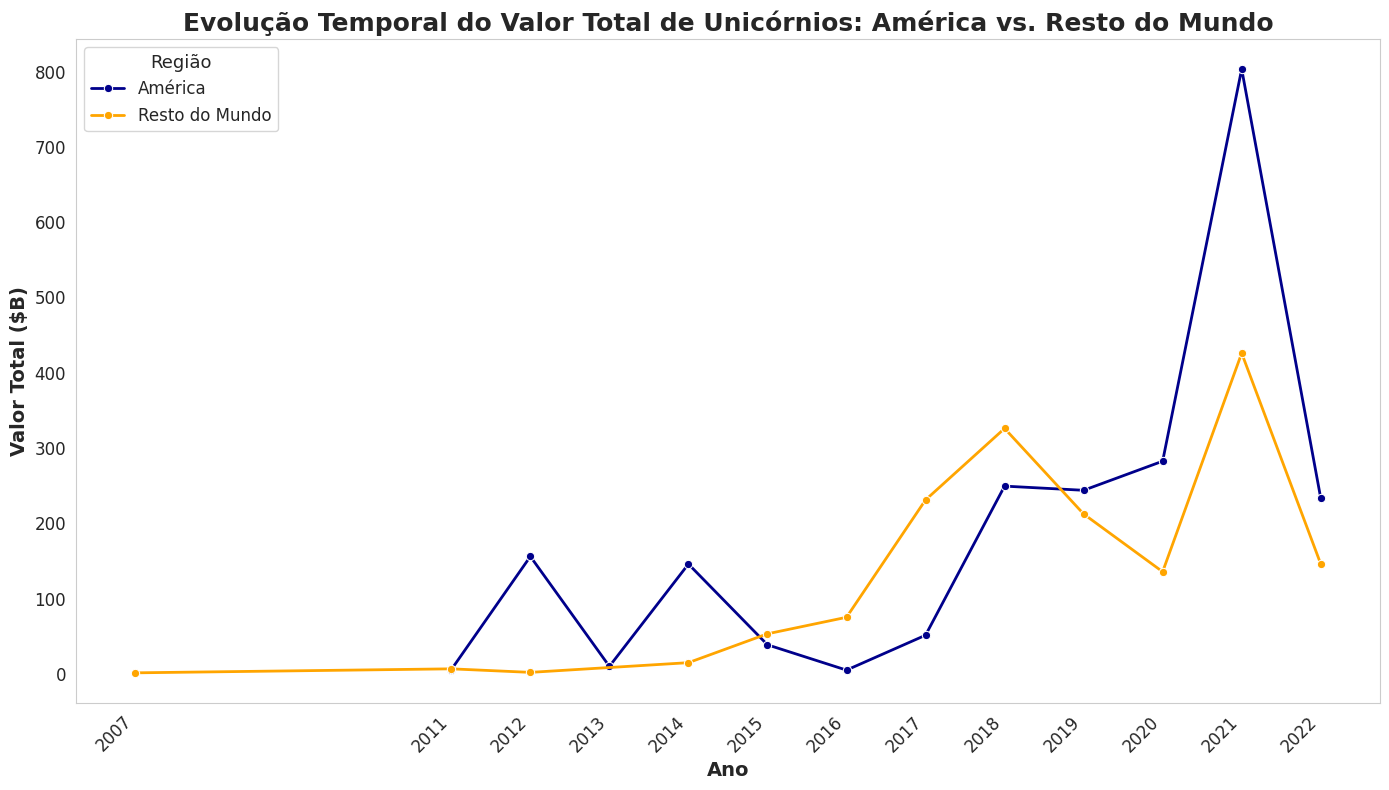

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filtrar os dados para o continente 'América'
america_data = Base_Dados[Base_Dados['Continente'] == 'América'].copy()

# Agrupar por ano e somar o valor total de unicórnios para a América
valor_total_por_ano_america = america_data.groupby('Ano')['Valor ($B)'].sum().reset_index()
valor_total_por_ano_america['Região'] = 'América'

# Filtrar os dados para o 'Resto do Mundo'
rest_of_world_data = Base_Dados[Base_Dados['Continente'] != 'América'].copy()

# Agrupar por ano e somar o valor total de unicórnios para o Resto do Mundo
valor_total_por_ano_rest_of_world = rest_of_world_data.groupby('Ano')['Valor ($B)'].sum().reset_index()
valor_total_por_ano_rest_of_world['Região'] = 'Resto do Mundo'

# Combinar os dois DataFrames
combined_valor_por_ano = pd.concat([valor_total_por_ano_america, valor_total_por_ano_rest_of_world])

# Configurar o estilo do gráfico
sns.set_style('whitegrid')
plt.figure(figsize=(14, 8))

# Plotar o gráfico de linhas
ax = sns.lineplot(
    x='Ano',
    y='Valor ($B)',
    hue='Região',
    data=combined_valor_por_ano,
    marker='o',
    palette={'América': 'darkblue', 'Resto do Mundo': 'orange'},
    linewidth=2
)


plt.title('Evolução Temporal do Valor Total de Unicórnios: América vs. Resto do Mundo', fontsize=18, fontweight='bold')
plt.xlabel('Ano', fontsize=14, fontweight='bold')
plt.ylabel('Valor Total ($B)', fontsize=14, fontweight='bold')
plt.xticks(combined_valor_por_ano['Ano'].unique().astype(int), rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Região', title_fontsize='13', fontsize='12')
plt.grid(False)
plt.tight_layout()
plt.show()

##**Visualização dos maiores unicórnios pos país na América**

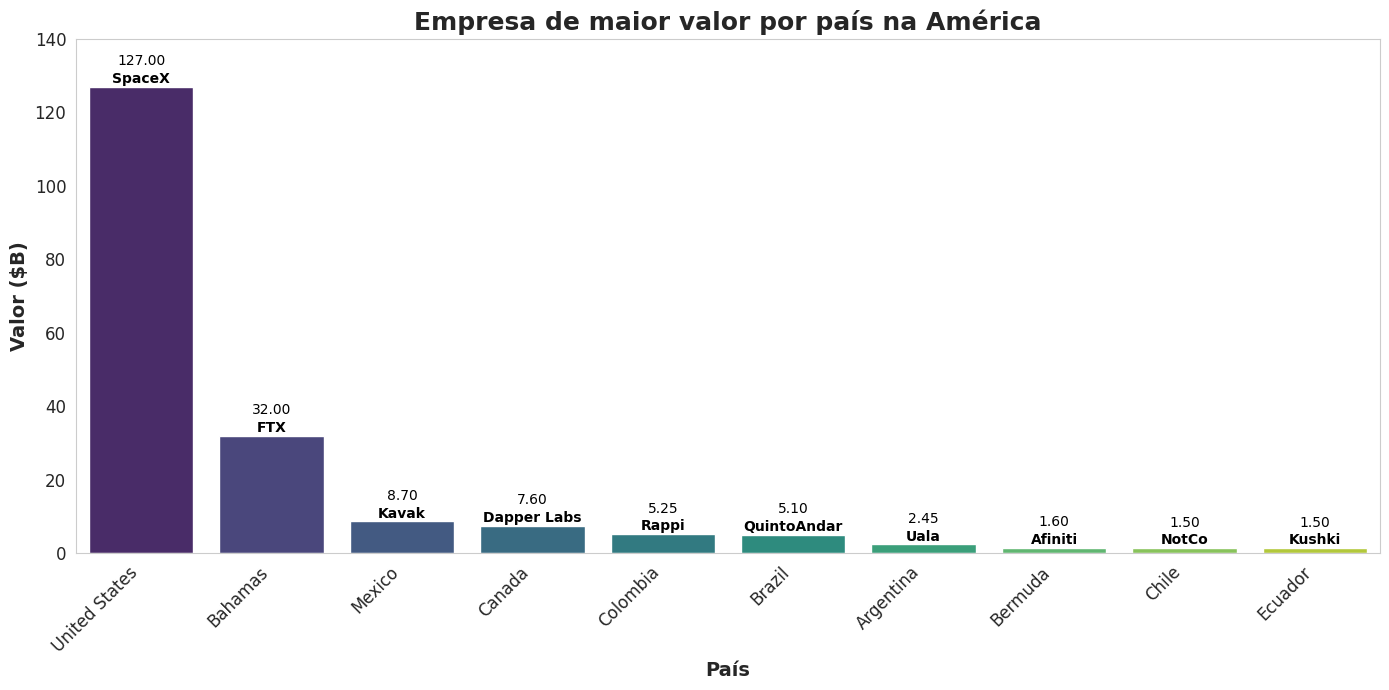

In [26]:
america_data = Base_Dados[Base_Dados['Continente'] == 'América']
top_companies_america = america_data.loc[america_data.groupby('Pais')['Valor ($B)'].idxmax()]
top_companies_america = top_companies_america[['Pais', 'Empresa', 'Valor ($B)']].reset_index(drop=True)

plt.figure(figsize=(14, 7))
# Sort the DataFrame by 'Valor ($)' in descending order
top_companies_america_sorted = top_companies_america.sort_values(by='Valor ($B)', ascending=False)

ax = sns.barplot(x='Pais', y='Valor ($B)', data=top_companies_america_sorted, palette='viridis', hue='Pais', legend=False)

plt.title('Empresa de maior valor por país na América', fontsize=18, fontweight='bold')
plt.xlabel('País', fontsize=14, fontweight='bold')
plt.ylabel('Valor ($B)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, 140)

# Adicionar rótulos de dados
for index, row in enumerate(top_companies_america_sorted.itertuples()):
    # Colocar o valor da empresa acima do nome
    ax.text(index, row._3 + 5.0, f'{row._3:.2f}', color='black', ha='center', va='bottom', fontsize=10) # Valor da empresa
    ax.text(index, row._3 + 0.2, row.Empresa, color='black', ha='center', va='bottom', fontsize=10, fontweight='bold') # Nome da empresa

plt.grid(axis='y', linestyle='--', alpha=0.0) # Set alpha to 0.0 to effectively hide horizontal grid lines
plt.tight_layout()
plt.show()

##**Valor total de unicórnios por setor na América**

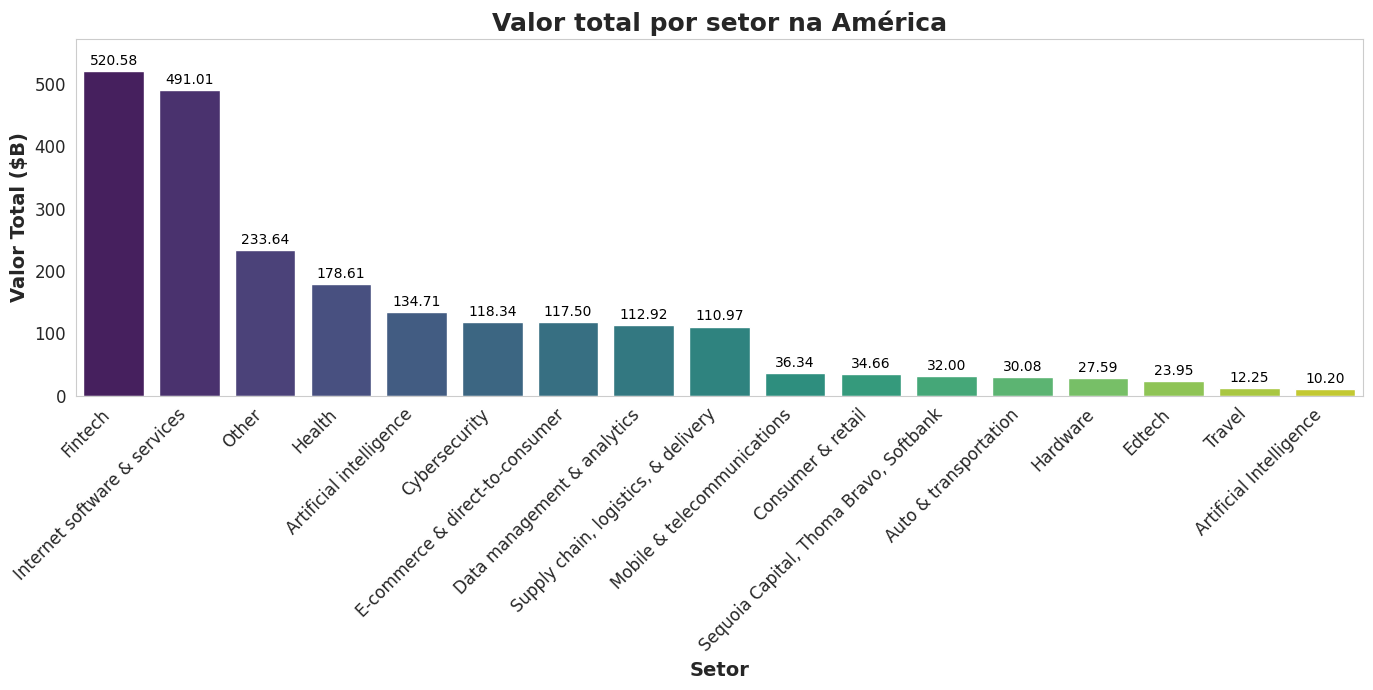

In [27]:
america_data = Base_Dados[Base_Dados['Continente'] == 'América']

# Calculate total value per country in America
total_value_per_country_america = america_data.groupby('Setor')['Valor ($B)'].sum().reset_index()
total_value_per_country_america_sorted = total_value_per_country_america.sort_values(by='Valor ($B)', ascending=False)

plt.figure(figsize=(14, 7))
ax = sns.barplot(x='Setor', y='Valor ($B)', data=total_value_per_country_america_sorted, palette='viridis', hue='Setor', legend=False)

plt.title('Valor total por setor na América', fontsize=18, fontweight='bold')
plt.xlabel('Setor', fontsize=14, fontweight='bold')
plt.ylabel('Valor Total ($B)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
# Adjust y-limit dynamically based on the max value, adding some padding
max_value = total_value_per_country_america_sorted['Valor ($B)'].max()
plt.ylim(0, max_value * 1.1)

# Adicionar rótulos de dados
for index, row in enumerate(total_value_per_country_america_sorted.itertuples()):
    ax.text(index, row._2 + 5.0, f'{row._2:.2f}', color='black', ha='center', va='bottom', fontsize=10) # Valor total

plt.grid(axis='y', linestyle='--', alpha=0.0)
plt.tight_layout()
plt.show()

##**Distribuição de unicórnios por cidade na América**

Top 10 Cidades com o maior número de unicórnios na América:


,Cidade,Número de Unicórnios
123,San Francisco,168
96,New York,111
14,Boston,21
102,Palo Alto,20
31,Chicago,17
94,Mountain View,17
117,Redwood City,12
132,Sao Paulo,12
125,San Mateo,11
4,Austin,10


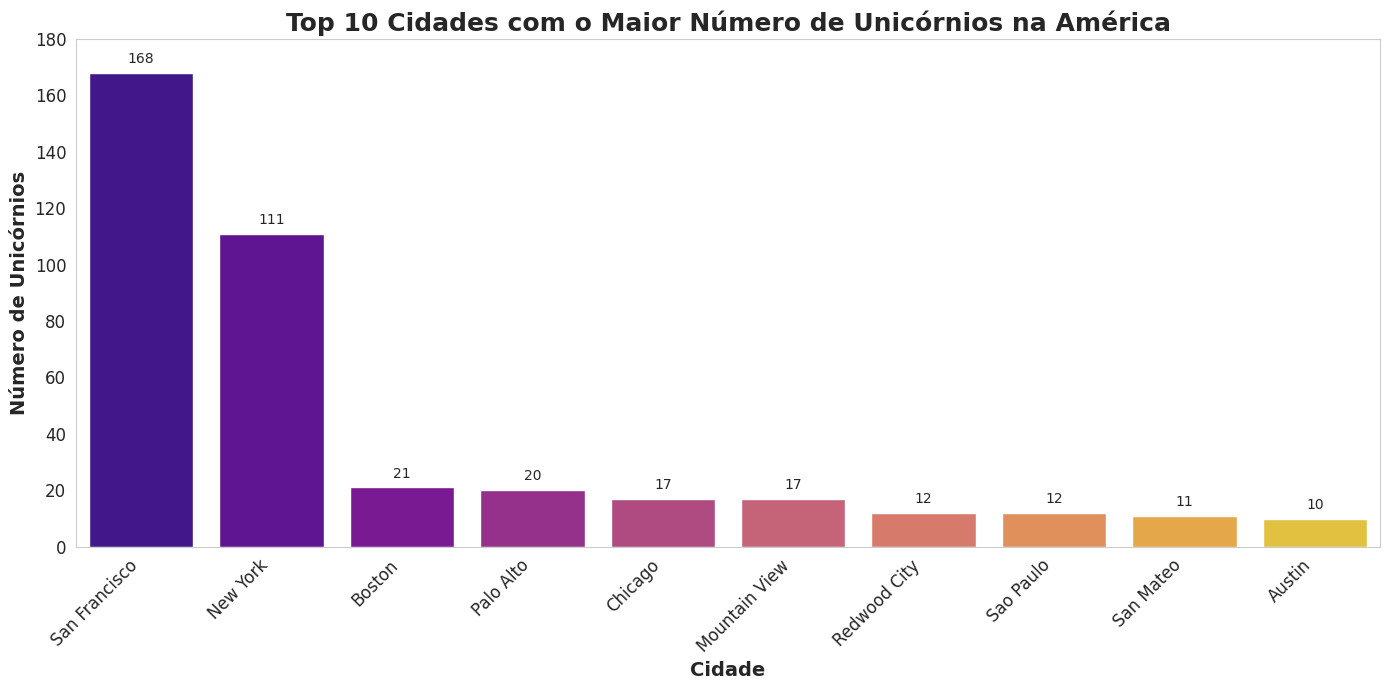

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Certificar que america_data está definida (já foi definida em células anteriores)
# america_data = Base_Dados[Base_Dados['Continente'] == 'América'].copy()

# Contar o número de unicórnios por cidade na América
unicorns_by_city_america = america_data.groupby('Cidade')['Empresa'].count().reset_index()
unicorns_by_city_america.columns = ['Cidade', 'Número de Unicórnios']

# Ordenar para pegar as top N cidades
top_cities_america = unicorns_by_city_america.sort_values(by='Número de Unicórnios', ascending=False).head(10)

print('Top 10 Cidades com o maior número de unicórnios na América:')
display(top_cities_america)

plt.figure(figsize=(14, 7))
ax = sns.barplot(x='Cidade', y='Número de Unicórnios', data=top_cities_america, palette='plasma', hue='Cidade', legend=False)

plt.title('Top 10 Cidades com o Maior Número de Unicórnios na América', fontsize=18, fontweight='bold')
plt.xlabel('Cidade', fontsize=14, fontweight='bold')
plt.ylabel('Número de Unicórnios', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.0)
plt.ylim(0, 180)

# Adicionar rótulos de dados
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

##**Top 10 paises com maior valor total de unicórnios e Top 10 setores globais por valor de unicórnios**

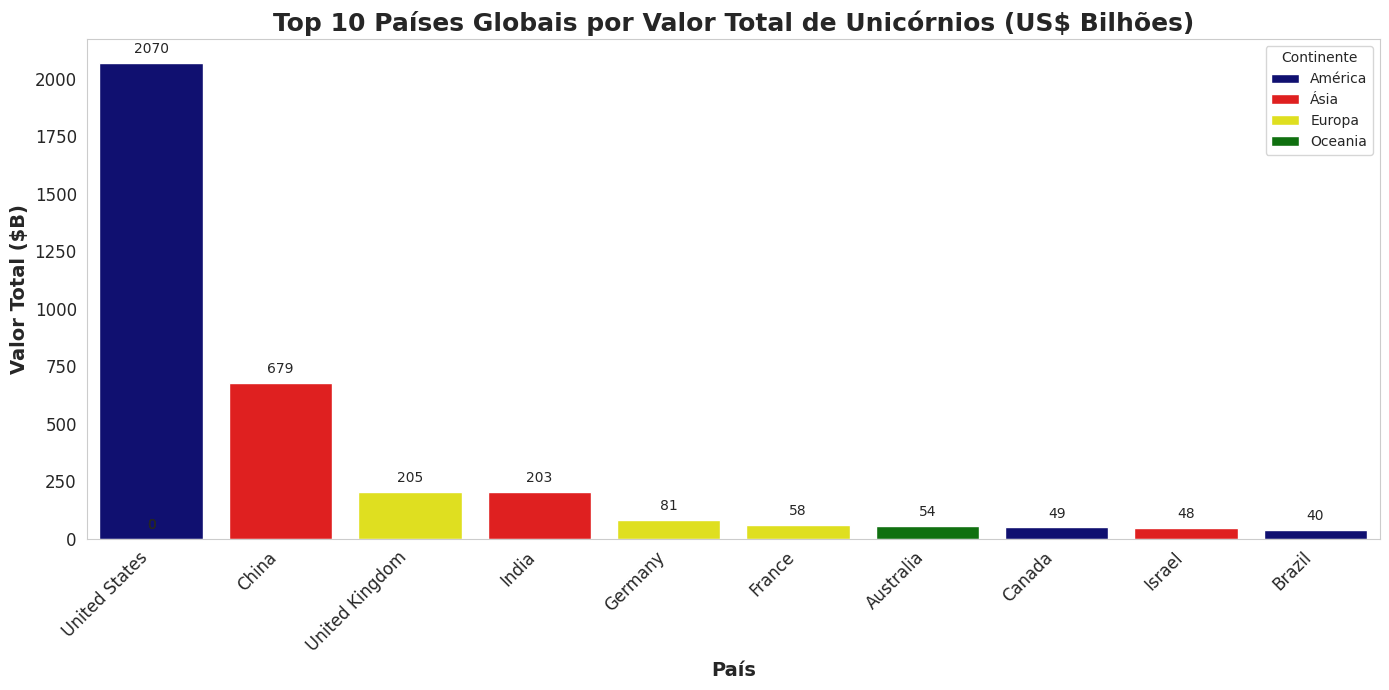

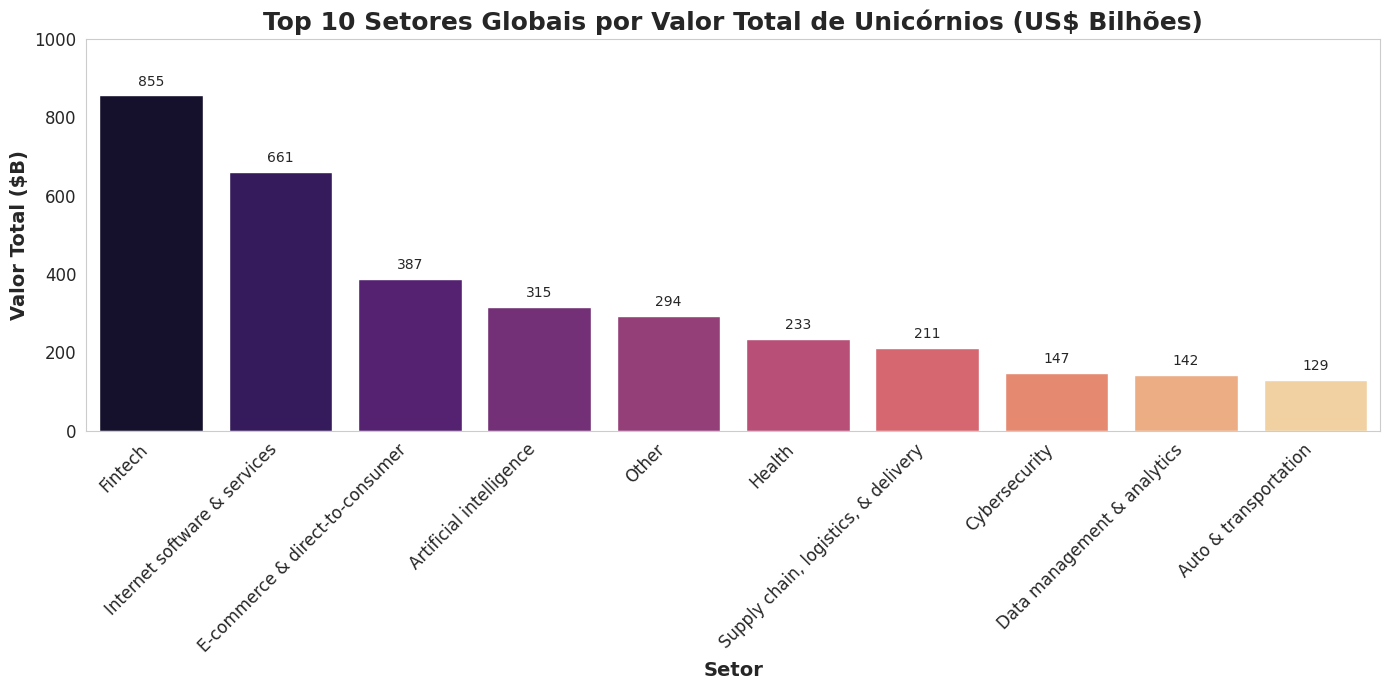

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Definir uma paleta de cores para os continentes
continent_palette = {
    'América': 'navy',
    'Ásia': 'red',
    'Europa': 'yellow',
    'Oceania': 'green',
    'África': 'lightsteelblue',
    'Outros': 'lightgray'
}

# --- Análise dos Top 10 Países Globais ---

# Agrupar por país e somar o valor total de unicórnios
top_10_paises_globais = Base_Dados.groupby('Pais')['Valor ($B)'].sum().reset_index()
top_10_paises_globais = top_10_paises_globais.sort_values(by='Valor ($B)', ascending=False).head(10)

# Adicionar a coluna 'Continente' ao DataFrame top_10_paises_globais
top_10_paises_globais = pd.merge(
    top_10_paises_globais,
    Base_Dados[['Pais', 'Continente']].drop_duplicates(),
    on='Pais',
    how='left'
)

plt.figure(figsize=(14, 7))
ax_paises = sns.barplot(
    x='Pais',
    y='Valor ($B)',
    data=top_10_paises_globais,
    hue='Continente',
    palette=continent_palette,
    legend=True # Show legend for continents
)
plt.title('Top 10 Países Globais por Valor Total de Unicórnios (US$ Bilhões)', fontsize=18, fontweight='bold')
plt.xlabel('País', fontsize=14, fontweight='bold')
plt.ylabel('Valor Total ($B)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.0)

# Adicionar rótulos de dados
for p in ax_paises.patches:
    ax_paises.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

# --- Análise dos Top 10 Setores Globais ---

# Agrupar por setor e somar o valor total de unicórnios
top_10_setores_globais = Base_Dados.groupby('Setor')['Valor ($B)'].sum().reset_index()
top_10_setores_globais = top_10_setores_globais.sort_values(by='Valor ($B)', ascending=False).head(10)

plt.figure(figsize=(14, 7))
ax_setores = sns.barplot(x='Setor', y='Valor ($B)', data=top_10_setores_globais, palette='magma', hue='Setor', legend=False)
plt.title('Top 10 Setores Globais por Valor Total de Unicórnios (US$ Bilhões)', fontsize=18, fontweight='bold')
plt.xlabel('Setor', fontsize=14, fontweight='bold')
plt.ylabel('Valor Total ($B)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.0)
plt.ylim(0, 1000)

# Adicionar rótulos de dados
for p in ax_setores.patches:
    ax_setores.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

##**Comparação entre os 10 maiores investidores globais vs. 10 maiores investidores na América**

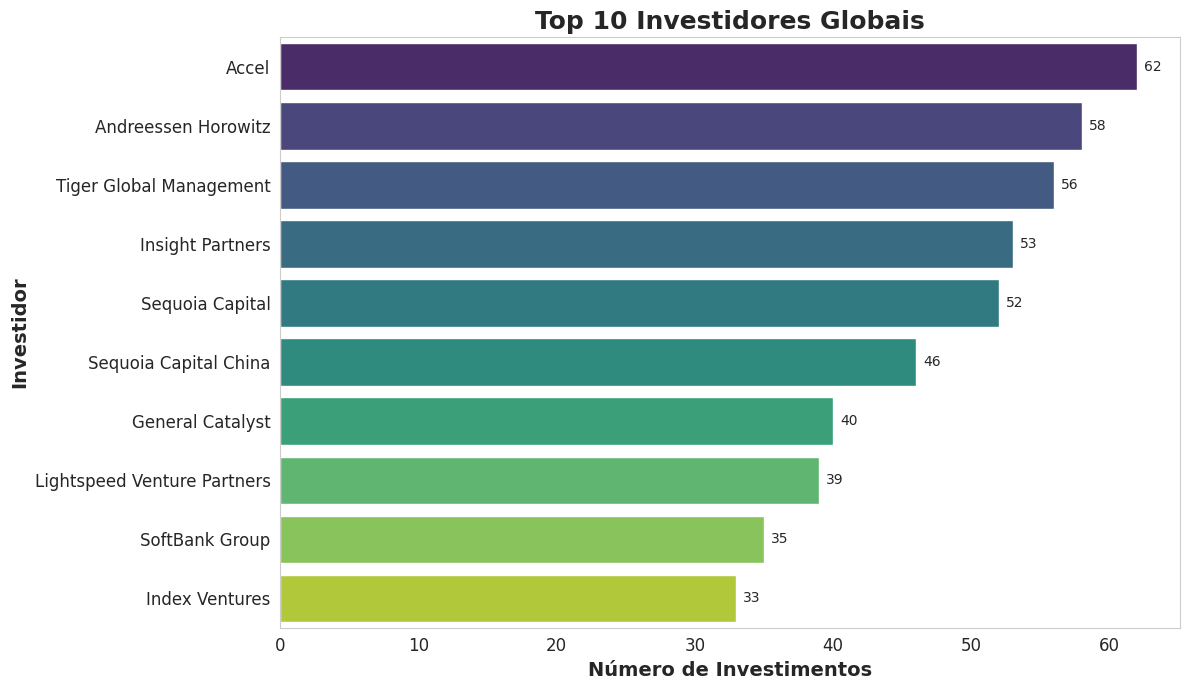

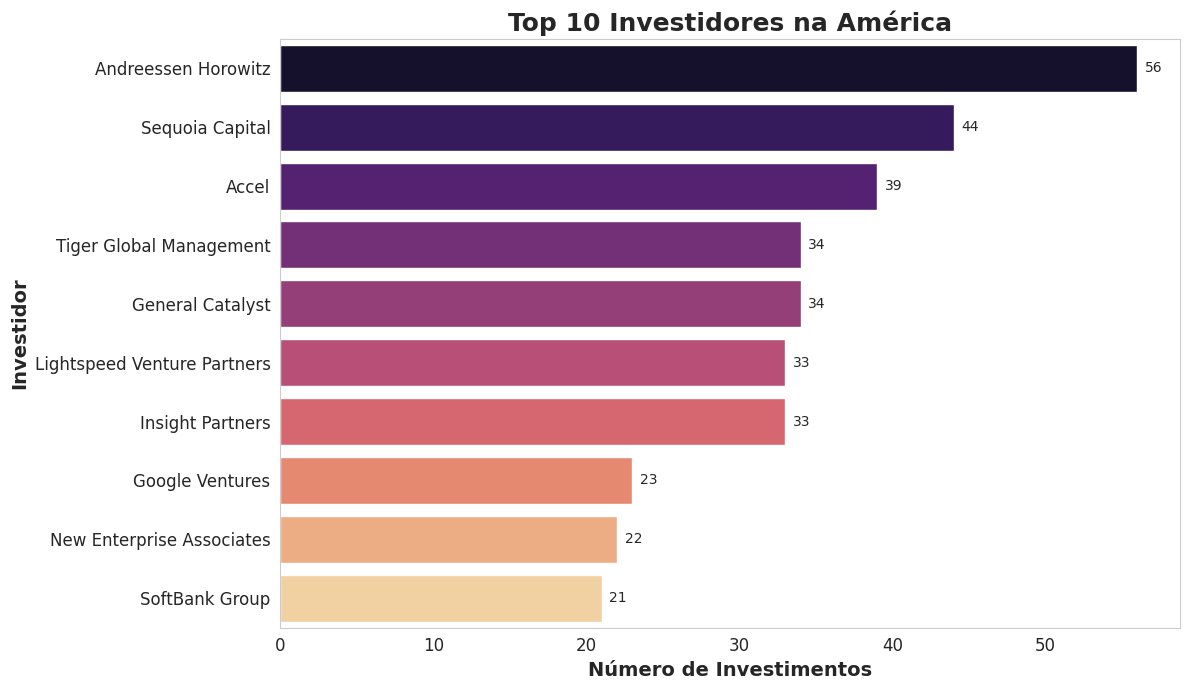

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular os top 10 investidores globais
investors_list = Base_Dados['Investidores'].dropna().str.split(', ').explode()
top_10_investors_global = investors_list.value_counts().head(10)

# Gráfico para os Top 10 Investidores Globais
plt.figure(figsize=(12, 7))
ax_global = sns.barplot(x=top_10_investors_global.values, y=top_10_investors_global.index, palette='viridis', hue=top_10_investors_global.index, legend=False)
plt.title('Top 10 Investidores Globais', fontsize=18, fontweight='bold')
plt.xlabel('Número de Investimentos', fontsize=14, fontweight='bold')
plt.ylabel('Investidor', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(False)

# Adicionar rótulos de dados nas barras
for p in ax_global.patches:
    plt.text(p.get_width() + 0.5, p.get_y() + p.get_height() / 2,
             '{:1.0f}'.format(p.get_width()),
             ha='left', va='center', fontsize=10)
plt.tight_layout()
plt.show()

# Calcular os top 10 investidores na América
america_investors_list = Base_Dados[Base_Dados['Continente'] == 'América']['Investidores'].dropna().str.split(', ').explode()
top_10_investors_america = america_investors_list.value_counts().head(10)

# Gráfico para os Top 10 Investidores na América
plt.figure(figsize=(12, 7))
ax_america = sns.barplot(x=top_10_investors_america.values, y=top_10_investors_america.index, palette='magma', hue=top_10_investors_america.index, legend=False)
plt.title('Top 10 Investidores na América', fontsize=18, fontweight='bold')
plt.xlabel('Número de Investimentos', fontsize=14, fontweight='bold')
plt.ylabel('Investidor', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(False)

# Adicionar rótulos de dados nas barras
for p in ax_america.patches:
    plt.text(p.get_width() + 0.5, p.get_y() + p.get_height() / 2,
             '{:1.0f}'.format(p.get_width()),
             ha='left', va='center', fontsize=10)
plt.tight_layout()
plt.show()

##**Setores com mais investimentos**

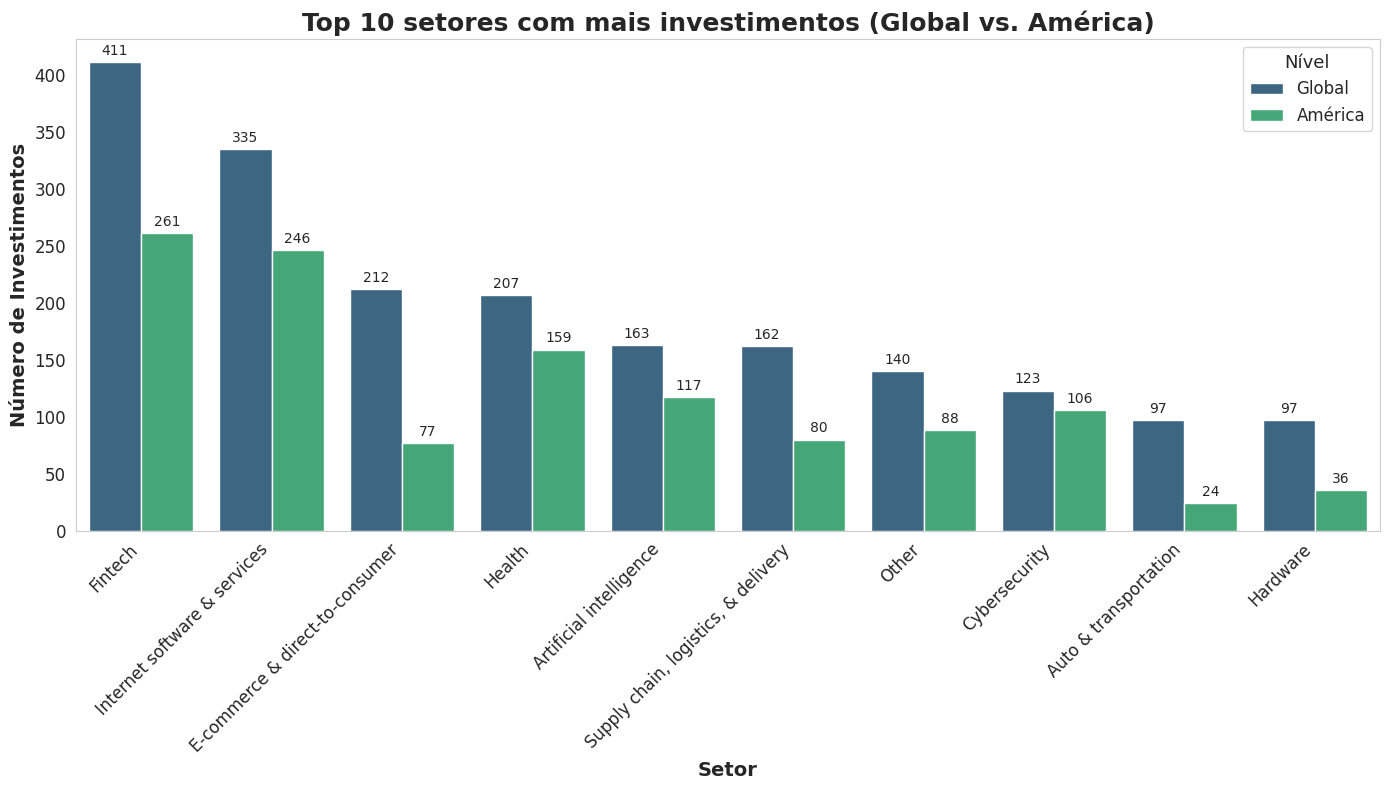

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Análise Global --- #
# Explode a coluna 'Investidores' para ter um investidor por linha
global_investors_exploded = Base_Dados.assign(Investor=Base_Dados['Investidores'].str.split(', ')).explode('Investor')
# Remove linhas onde o investidor é nulo (pode ocorrer de 'Investidores' ser NaN ou vazia)
global_investors_exploded = global_investors_exploded.dropna(subset=['Investor'])

# Conta o número de investidores únicos por setor globalmente
global_sector_investor_counts = global_investors_exploded.groupby('Setor')['Investor'].nunique().reset_index()
global_sector_investor_counts.rename(columns={'Investor': 'Numero_De_Investidores_Global'}, inplace=True)

# Obtém os 10 principais setores globais com base no número de investidores únicos
top_10_global_sectors = global_sector_investor_counts.sort_values(by='Numero_De_Investidores_Global', ascending=False).head(10)['Setor'].tolist()

# --- Análise do Continente Americano --- #
# Filtra os dados para o continente 'América'
america_data = Base_Dados[Base_Dados['Continente'] == 'América'].copy()

# Explode a coluna 'Investidores' para os dados da América
america_investors_exploded = america_data.assign(Investor=america_data['Investidores'].str.split(', ')).explode('Investor')
america_investors_exploded = america_investors_exploded.dropna(subset=['Investor'])

# Conta o número de investidores únicos por setor na América
america_sector_investor_counts = america_investors_exploded.groupby('Setor')['Investor'].nunique().reset_index()
america_sector_investor_counts.rename(columns={'Investor': 'Numero_De_Investidores_America'}, inplace=True)

# --- Combina e Prepara para Visualização --- #
# Filtra os dados globais e americanos para incluir apenas os top 10 setores globais
global_plot_data = global_sector_investor_counts[global_sector_investor_counts['Setor'].isin(top_10_global_sectors)].copy()
america_plot_data = america_sector_investor_counts[america_sector_investor_counts['Setor'].isin(top_10_global_sectors)].copy()

# Mescla os dataframes pelos 'Setor', preenchendo valores NaN com 0 para setores sem investidores na América
merged_investor_counts = pd.merge(global_plot_data, america_plot_data, on='Setor', how='left').fillna(0)
# Garante que a coluna de investidores da América é numérica (int)
merged_investor_counts['Numero_De_Investidores_America'] = merged_investor_counts['Numero_De_Investidores_America'].astype(int)

# Ordena o DataFrame mesclado pelo número de investidores globais para uma ordem consistente no gráfico
merged_investor_counts = merged_investor_counts.sort_values(by='Numero_De_Investidores_Global', ascending=False)

# Transforma o DataFrame para o formato 'long' para o seaborn barplot (melt)
plot_df = merged_investor_counts.melt(id_vars='Setor', var_name='Nivel', value_name='Numero_De_Investidores')
# Renomeia os níveis para melhor legibilidade no gráfico
plot_df['Nivel'] = plot_df['Nivel'].replace({
    'Numero_De_Investidores_Global': 'Global',
    'Numero_De_Investidores_America': 'América'
})

# --- Visualização --- #
plt.figure(figsize=(14, 8))
ax = sns.barplot(
    x='Setor',
    y='Numero_De_Investidores',
    hue='Nivel',
    data=plot_df,
    palette='viridis'
)

plt.title('Top 10 setores com mais investimentos (Global vs. América)', fontsize=18, fontweight='bold')
plt.xlabel('Setor', fontsize=14, fontweight='bold')
plt.ylabel('Número de Investimentos', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Nível', fontsize=12, title_fontsize='13')
plt.grid(axis='y', linestyle='--', alpha=0.0)

# Adiciona rótulos de dados nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10, padding=3)

plt.tight_layout()
plt.show()

##**Evolução cumulativa dos 5 maiores setores na América**

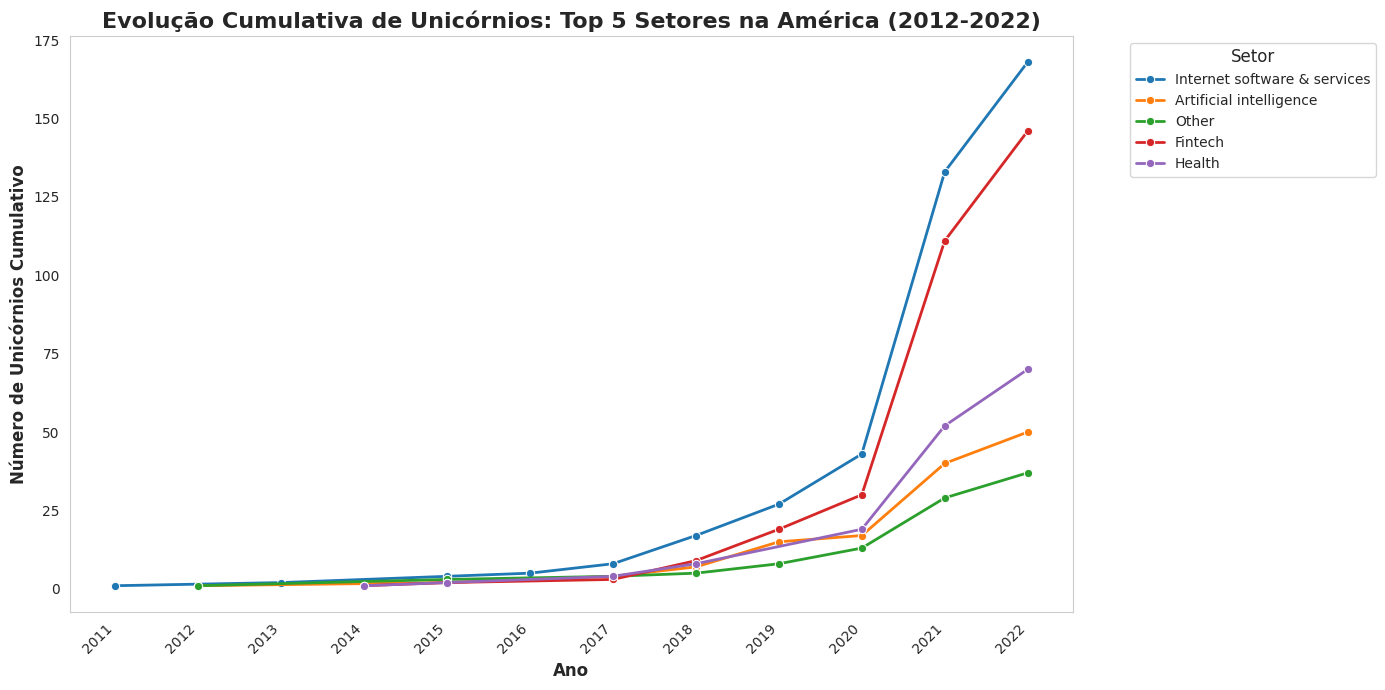

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filtrar os dados para o continente 'América'
america_data = Base_Dados[Base_Dados['Continente'] == 'América'].copy()

# Identificar os 5 principais setores por valor total na América
top_5_sectors_america_names = america_data.groupby('Setor')['Valor ($B)'].sum().nlargest(5).reset_index()['Setor'].tolist()

# Filtrar os dados da América para incluir apenas os top 5 setores
filtered_america_data_top5_sectors = america_data[america_data['Setor'].isin(top_5_sectors_america_names)].copy()

# Calcular a contagem anual de unicórnios para cada um dos top 5 setores
yearly_sector_counts = filtered_america_data_top5_sectors.groupby(['Ano', 'Setor'])['Empresa'].count().reset_index()
yearly_sector_counts.rename(columns={'Empresa': 'Número de Unicórnios'}, inplace=True)

# Calcular a soma cumulativa de unicórnios para cada setor
yearly_sector_counts['Número de Unicórnios Cumulativo'] = yearly_sector_counts.groupby('Setor')['Número de Unicórnios'].cumsum()

# Configurar o estilo do gráfico
sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))

# Plotar o gráfico de linha com valores cumulativos para os top 5 setores
ax = sns.lineplot(
    x='Ano',
    y='Número de Unicórnios Cumulativo',
    hue='Setor',
    data=yearly_sector_counts,
    marker='o',
    palette='tab10', # Usando uma paleta adequada para múltiplas categorias
    linewidth=2
)

plt.title('Evolução Cumulativa de Unicórnios: Top 5 Setores na América (2012-2022)', fontsize=16, fontweight='bold')
plt.xlabel('Ano', fontsize=12, fontweight='bold')
plt.ylabel('Número de Unicórnios Cumulativo', fontsize=12, fontweight='bold')
plt.xticks(yearly_sector_counts['Ano'].unique().astype(int), rotation=45, ha='right')
plt.yticks(fontsize=10)
plt.legend(title='Setor', title_fontsize='12', fontsize='10', bbox_to_anchor=(1.05, 1), loc='upper left') # Ajustar a posição da legenda
plt.grid(False)


plt.tight_layout()
plt.show()

##**Efeito pandemia**

###Este heatmap avalia o número de investidores antes e durante/após a pandemia da covid-19

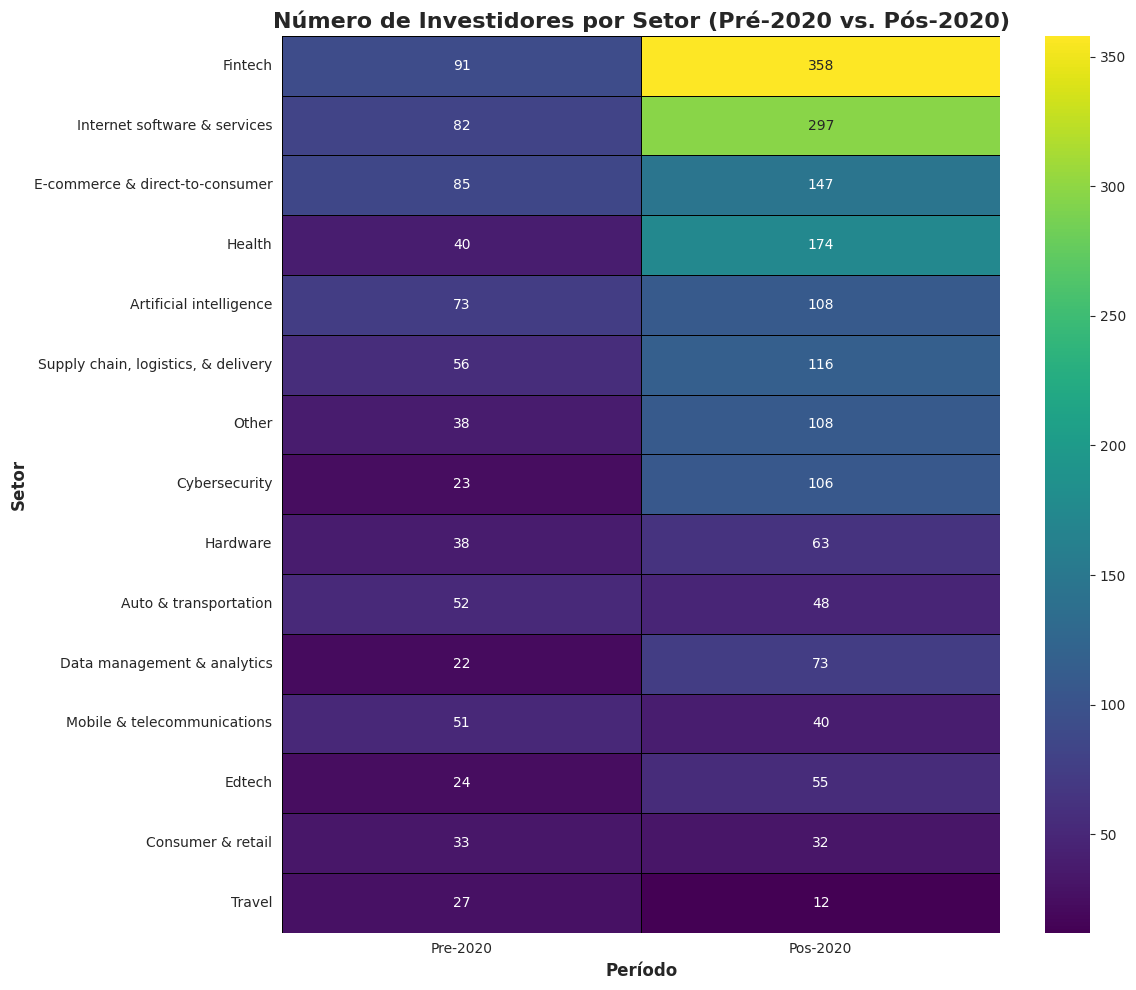

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Certificar que a coluna 'Periodo' está definida
if 'Periodo' not in Base_Dados.columns:
    Base_Dados['Periodo'] = Base_Dados['Ano'].apply(lambda x: 'Pre-2020' if x < 2020 else 'Pos-2020')

# Filtrar os dados para cada período
pre_2020_data = Base_Dados[Base_Dados['Periodo'] == 'Pre-2020'].copy()
pos_2020_data = Base_Dados[Base_Dados['Periodo'] == 'Pos-2020'].copy()

# Explodir os investidores para cada período
pre_2020_investors_exploded = pre_2020_data.assign(Investor=pre_2020_data['Investidores'].str.split(', ')).explode('Investor')
pos_2020_investors_exploded = pos_2020_data.assign(Investor=pos_2020_data['Investidores'].str.split(', ')).explode('Investor')

# Remover linhas com investidores nulos após a explosão
pre_2020_investors_exploded = pre_2020_investors_exploded.dropna(subset=['Investor'])
pos_2020_investors_exploded = pos_2020_investors_exploded.dropna(subset=['Investor'])

# Combinar os dataframes explodidos e calcular investidores únicos por setor e período
combined_investors_exploded = pd.concat([pre_2020_investors_exploded, pos_2020_investors_exploded])
investor_counts_by_sector_period = combined_investors_exploded.groupby(['Setor', 'Periodo'])['Investor'].nunique().unstack(fill_value=0)

# Calcular o total de investidores por setor para ordenar e selecionar os mais relevantes
investor_counts_by_sector_period['Total_Investidores'] = investor_counts_by_sector_period.sum(axis=1)
investor_counts_by_sector_period = investor_counts_by_sector_period.sort_values(by='Total_Investidores', ascending=False).drop(columns='Total_Investidores')

# Selecionar os top N setores para uma melhor visualização no heatmap
top_n_sectors = investor_counts_by_sector_period.head(15)

top_n_sectors = top_n_sectors[['Pre-2020', 'Pos-2020']]


# Visualização do Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(top_n_sectors, annot=True, fmt='d', cmap='viridis', linewidths=.5, linecolor='black')
plt.title('Número de Investidores por Setor (Pré-2020 vs. Pós-2020)', fontsize=16, fontweight='bold')
plt.xlabel('Período', fontsize=12, fontweight='bold')
plt.ylabel('Setor', fontsize=12, fontweight='bold')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()

###Como o campo Pré-2020 vai até 2012, foi utilizada uma estratégia para consultar somente os dados de 2 anos pré-pandemia (2018) e dois anos pós-pandemia (2022)

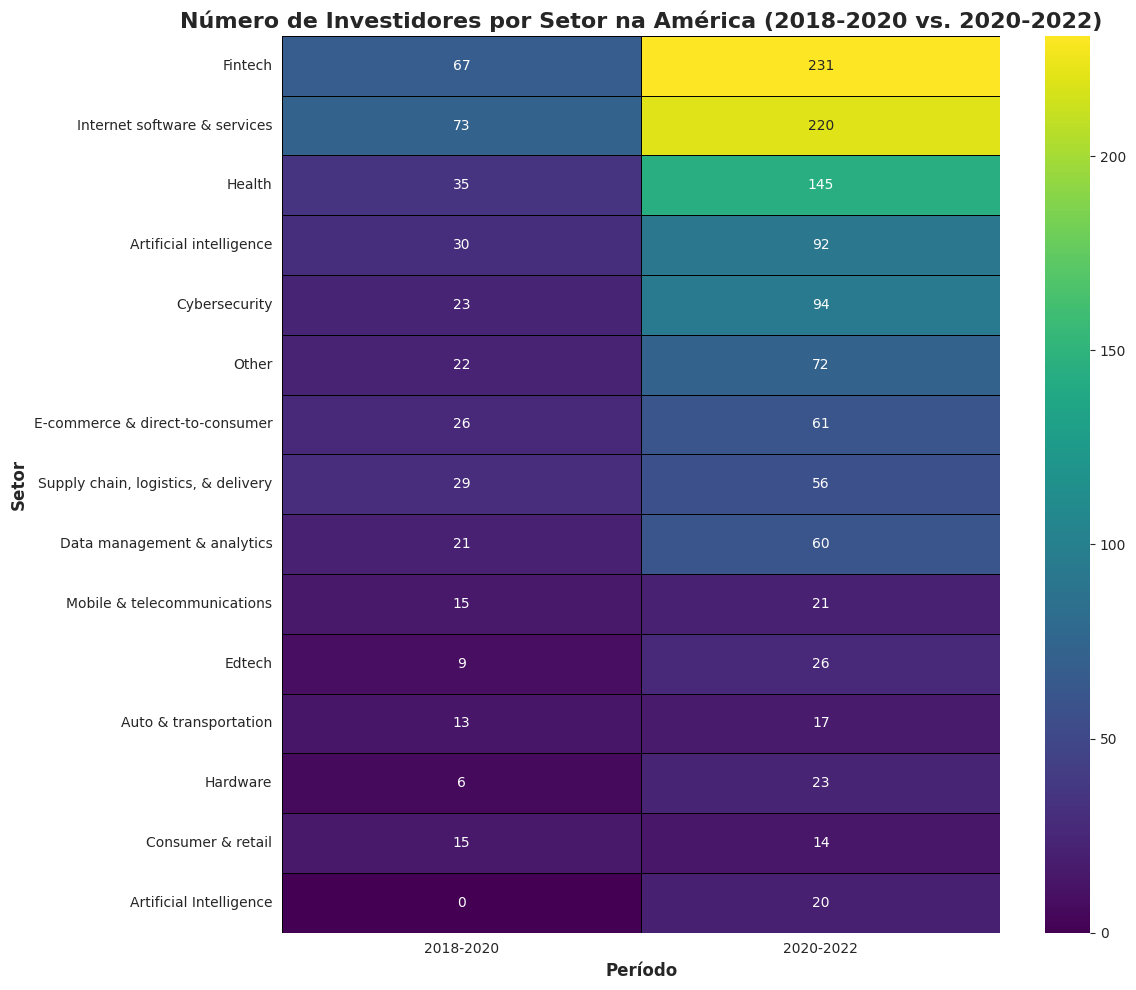

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Re-load and preprocess Base_Dados to ensure it's defined and correctly formatted
# This step is included for robustness, assuming Base_Dados might not always be in the expected state.
Base_Dados = pd.read_csv('unicorns till sep 2022.csv')

Base_Dados.rename(columns={
    'Company': 'Empresa',
    'Valuation ($B)': 'Valor ($B)',
    'Date Joined': 'Data de Entrada',
    'Country': 'Pais',
    'City\xa0': 'Cidade',
    'Industry': 'Setor',
    'Investors': 'Investidores'
}, inplace=True)

Base_Dados['Valor ($B)'] = Base_Dados['Valor ($B)'].astype(str).str.replace('$', '', regex=False).astype(float)
Base_Dados['Data de Entrada'] = pd.to_datetime(Base_Dados['Data de Entrada'])
Base_Dados['Ano'] = pd.DatetimeIndex(Base_Dados['Data de Entrada']).year

def get_continent(country):
    if country in ['Bahamas', 'Bermuda', 'United States', 'Canada', 'Mexico', 'Brazil', 'Argentina', 'Chile', 'Colombia', 'Peru', 'Ecuador', 'Venezuela']:
        return 'América'
    elif country in ['China', 'India', 'Japan', 'South Korea', 'Indonesia', 'Singapore', 'Israel', 'United Arab Emirates', 'Hong Kong', 'Taiwan', 'Vietnam', 'Philippines', 'Malaysia', 'Thailand', 'Pakistan', 'Saudi Arabia', 'Cambodia']:
        return 'Ásia'
    elif country in ['United Kingdom', 'Germany', 'France', 'Netherlands', 'Sweden', 'Switzerland', 'Ireland', 'Spain', 'Finland', 'Belgium', 'Norway', 'Denmark', 'Italy', 'Estonia', 'Lithuania', 'Austria', 'Luxembourg', 'Poland', 'Czech Republic', 'Portugal', 'Russia', 'Turkey', 'Ukraine', 'Hungary', 'Slovakia', 'Croatia', 'Bulgaria', 'Romania']:
        return 'Europe'
    elif country in ['Australia', 'New Zealand']:
        return 'Oceania'
    elif country in ['South Africa', 'Nigeria', 'Egypt', 'Kenya','Seychelles', 'Senegal']:
        return 'África'
    else:
        return 'Outros'

Base_Dados['Continente'] = Base_Dados['Pais'].apply(get_continent)

# Filter data for the 'América' continent
america_data = Base_Dados[Base_Dados['Continente'] == 'América'].copy()

# Define the two periods as requested
period_2018_2020_years = [2018, 2019, 2020]
period_2020_2022_years = [2020, 2021, 2022] # This period includes 2020, 2021, 2022

# Filter America data for each period
america_data_period1 = america_data[america_data['Ano'].isin(period_2018_2020_years)].copy()
america_data_period2 = america_data[america_data['Ano'].isin(period_2020_2022_years)].copy()

# Explode investors and count unique ones for Period 1 (2018-2020)
exploded_investors_period1 = america_data_period1.assign(Investor=america_data_period1['Investidores'].str.split(', ')).explode('Investor')
counts_period1 = exploded_investors_period1.dropna(subset=['Investor']).groupby('Setor')['Investor'].nunique().reset_index()
counts_period1.rename(columns={'Investor': '2018-2020'}, inplace=True)

# Explode investors and count unique ones for Period 2 (2020-2022)
exploded_investors_period2 = america_data_period2.assign(Investor=america_data_period2['Investidores'].str.split(', ')).explode('Investor')
counts_period2 = exploded_investors_period2.dropna(subset=['Investor']).groupby('Setor')['Investor'].nunique().reset_index()
counts_period2.rename(columns={'Investor': '2020-2022'}, inplace=True)

# Merge the counts for both periods
heatmap_data = pd.merge(counts_period1, counts_period2, on='Setor', how='outer').fillna(0)

# Ensure investor counts are integers
heatmap_data['2018-2020'] = heatmap_data['2018-2020'].astype(int)
heatmap_data['2020-2022'] = heatmap_data['2020-2022'].astype(int)

# Sort by total investors or a specific period for better visualization
heatmap_data['Total_Investidores'] = heatmap_data['2018-2020'] + heatmap_data['2020-2022']
heatmap_data = heatmap_data.sort_values(by='Total_Investidores', ascending=False).drop(columns='Total_Investidores')

# Set 'Setor' as index for the heatmap
heatmap_data_pivot = heatmap_data.set_index('Setor')

# Explicitly set the column order to ensure '2018-2020' is on the left and '2020-2022' on the right
top_n_sectors = heatmap_data_pivot.head(15)[['2018-2020', '2020-2022']]

# Visualização do Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(top_n_sectors, annot=True, fmt='d', cmap='viridis', linewidths=.5, linecolor='black')
plt.title('Número de Investidores por Setor na América (2018-2020 vs. 2020-2022)', fontsize=16, fontweight='bold')
plt.xlabel('Período', fontsize=12, fontweight='bold')
plt.ylabel('Setor', fontsize=12, fontweight='bold')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()

##**Distribuição dos valores dos unicórnios na América**

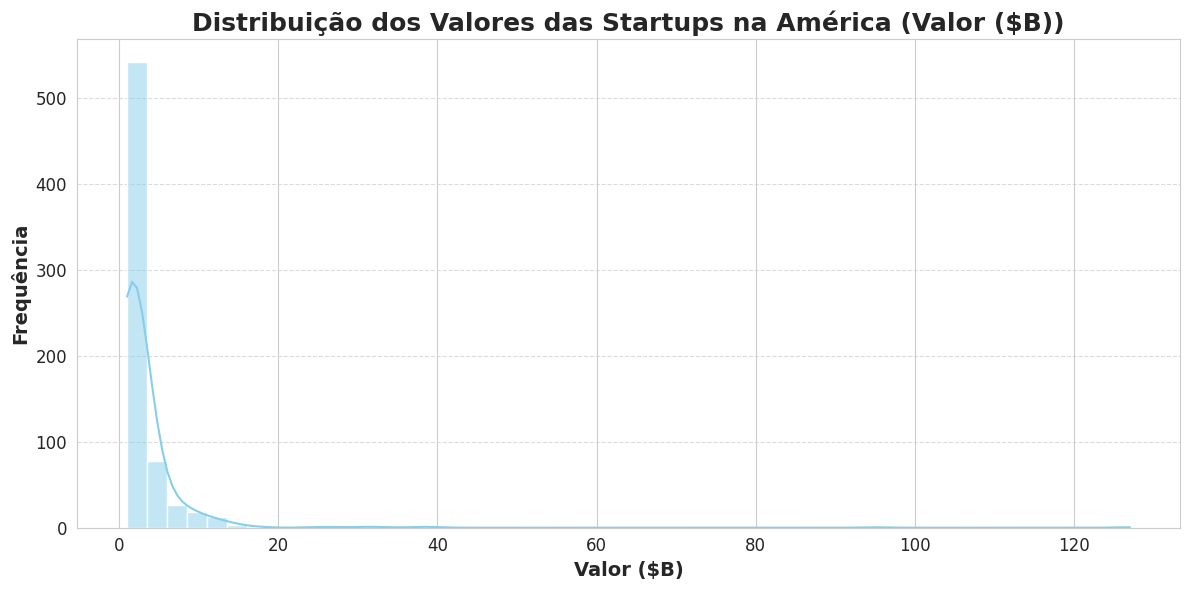

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(america_data['Valor ($B)'], bins=50, kde=True, color='skyblue')
plt.title('Distribuição dos Valores das Startups na América (Valor ($B))', fontsize=18, fontweight='bold')
plt.xlabel('Valor ($B)', fontsize=14, fontweight='bold')
plt.ylabel('Frequência', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Conclusão da Análise de Startups Unicórnios**

Este estudo aprofundou a evolução das startups unicórnios até 2022, com um foco particular no continente americano, mas também apresentando comparações globais que enriquecem o entendimento do cenário. Os dados revelam uma ascensão notável de empresas privadas avaliadas em mais de US$1 bilhão, um fenômeno impulsionado por diversos fatores e com concentrações geográficas e setoriais distintas.

### **Domínio Americano no Cenário Global**

A América emerge como o continente líder em diversos aspectos:
*   **Valor Total de Investimentos**: O continente Americano concentra o maior volume de capital investido em unicórnios, superando significativamente o Resto do Mundo, conforme demonstrado no gráfico de evolução temporal de valor total.
*   **Número de Unicórnios e Países**: A América também possui o maior número de unicórnios e lidera na quantidade de países com startups unicórnios, evidenciando uma base diversificada de inovação e investimento.
*   **Evolução Temporal**: A curva de crescimento de novos unicórnios na América mostra uma aceleração notável, especialmente a partir de meados da década de 2010, mantendo um ritmo robusto até 2022.

No entanto, a análise por país dentro da América revela uma forte concentração nos **Estados Unidos**, que dominam amplamente o cenário. Empresas como a SpaceX exemplificam o alto valor gerado nessas regiões. Cidades como **San Francisco e Nova York** são, sem surpresa, os principais *hubs* de unicórnios no continente, refletindo ecossistemas de inovação maduros e vibrantes.

### **Setores em Destaque**

Globalmente e na América, os setores de **Fintech (tecnologia financeira) e Internet Software & Services (software e serviços de internet)** são os mais proeminentes, tanto em termos de valor total quanto no número de investidores. Estes setores demonstraram maior capacidade de atrair capital e gerar empresas de alto valor. A evolução cumulativa dos top 5 setores na América também reforça essa tendência, com Fintech e Internet Software & Services liderando o crescimento ao longo dos anos.

### **O Efeito Pandemia (2020-2022)**

A análise do período pandêmico (Pós-2020) versus o pré-pandemia (Pré-2020) no heatmap de investidores por setor indica um aumento geral na atividade de investimentos. Muitos setores registraram um número maior de investidores únicos no período Pós-2020, sugerindo que, apesar dos desafios globais, o ecossistema de startups unicórnios se manteve resiliente e até prosperou em certas áreas, atraindo mais capital e investidores. Em especial na América, observou-se um crescimento considerável no número de investidores em diversos setores.

### **Considerações Finais**

O cenário de startups unicórnios é dinâmico e continua a evoluir rapidamente. A concentração de valor e atividade na América, particularmente nos Estados Unidos, e o protagonismo de setores como Fintech e Software & Serviços de Internet, são tendências claras. A resiliência do setor de investimentos durante e após a pandemia também é um indicativo da robustez e do potencial de crescimento contínuo dessas empresas de alto impacto.